### installing libraries

In [208]:
import sys
import os
#sys.path.append(r"C:\Users\aryan\AppData\Roaming\Python\Python311\site-packages")
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
np.NaN=np.nan
import pandas_ta as ta
from typing import Tuple
import vectorbt as vbt
import tqdm
from tabulate import tabulate
from functions_ import *


### zscore function(needs optimisation)

In [209]:
def z_score(start_date, end_date, universe,rolling_threshold, period,mean_period):
    # Load the appropriate stock list based on the universe
    if universe == 'Small Cap':
        symbols_df = pd.read_csv('data/niftysmallcap100/ind_niftysmallcap100list.csv')
    elif universe == 'Large Cap':
        symbols_df = pd.read_csv('data/nifty50/ind_nifty50list.csv')
    elif universe == 'Mid Cap':
        symbols_df = pd.read_csv('data/niftymidcap100/ind_niftymidcap100list.csv')
    elif universe == 'Micro Cap':
        symbols_df = pd.read_csv('data/niftymicrocap250/ind_niftymicrocap250_list.csv')
    elif universe == 'All Cap':
        symbols_df = pd.read_csv('data/nifty500/ind_nifty500list.csv')

    symbols = symbols_df['Symbol'].tolist()
    
    # Load weekly closing prices
    weekly_close = pd.read_csv('split_ohlcv_data/all_close.csv', parse_dates=['Date'], index_col='Date')
    #print(weekly_close.columns)
    # Ensure only available symbols are selected
    available_symbols = [symbol+".NS" for symbol in symbols if symbol+".NS" in weekly_close.columns]
    if not available_symbols:
        raise ValueError("None of the selected symbols are present in weekly_close.csv")

    # Slice data according to start and end date
    weekly_close = weekly_close.loc[start_date:end_date, available_symbols]
    # Calculate weekly returns 
    weekly_returns = np.log(weekly_close / weekly_close.shift(1))

    # Calculate rolling mean and std deviation for the period
    rolling_mean = weekly_returns.rolling(window=period).mean()
    rolling_std = weekly_returns.rolling(window=period).std()

    # Calculate Z-score with condition
    z_scores = np.where(
        rolling_mean >= rolling_threshold,  # Ensure rolling mean is positive
        (weekly_returns - rolling_mean) / rolling_std,
        -9999
    )

    # Assign -9999 where there are NaN values or where data is insufficient
    z_scores_df = pd.DataFrame(z_scores, index=weekly_returns.index, columns=weekly_returns.columns)
    z_scores_df = z_scores_df.fillna(-9999)  # Fill missing values with -9999

    # Save Z-scores to CSV
    z_scores_df.to_csv('z_scores.csv')

    # Compute rolling mean of period 4 for Z-scores
    z_scores_mean_df = z_scores_df.rolling(window=mean_period).mean().fillna(-9999)

    # Save the rolling mean Z-scores to CSV
    z_scores_mean_df.to_csv('z_scores_mean.csv')

    return z_scores_df, z_scores_mean_df

### global variables


In [205]:

START_DATE = "2017-01-01"
END_DATE = "2024-01-01"#datetime.today().strftime('%Y-%m-%d')
INTERVALS = 'data/nifty500/nifty500_daily_ohlcv.csv'
universe_files = {
    'Small Cap': 'ind_niftysmallcap100list.csv',
    'Large Cap': 'ind_nifty50list.csv',
    'Mid Cap': 'ind_niftymidcap100list.csv',
    'Micro Cap': 'ind_niftymicrocap250_list.csv',
    'All Cap': 'data/nifty500/ind_nifty500list.csv'
}

### fetch data

In [207]:

df = pd.read_csv(r'data/nifty500/ind_nifty500list.csv')
tickers = [f"{symbol}.NS" for symbol in df['Symbol']]
data = yf.download(
    tickers=tickers,
    start=START_DATE,       
    end=END_DATE,
    interval='1wk',   # Daily interval
    group_by='ticker',   # Organize data by ticker
    auto_adjust=False,   # Keep original OHLC values
    threads=True         # Parallelize downloads
)
    # 3. Save to CSV
data.to_csv(INTERVALS, index=True)

[*********************100%***********************]  500 of 500 completed

32 Failed downloads:
['INDGN.NS', 'SAGILITY.NS', 'HYUNDAI.NS', 'FIRSTCRY.NS', 'AIIL.NS', 'EMCURE.NS', 'UNITDSPR.NS', 'NIVABUPA.NS', 'SWIGGY.NS', 'RAYMONDLSL.NS', 'BHARTIHEXA.NS', 'AFCONS.NS', 'SAILIFE.NS', 'ACMESOLAR.NS', 'AKUMS.NS', 'PREMIERENE.NS', 'AEGISLOG.NS', 'COHANCE.NS', 'ETERNAL.NS', 'JYOTICNC.NS', 'IKS.NS', 'GODIGIT.NS', 'NTPCGREEN.NS', 'HBLENGINE.NS', 'OLAELEC.NS', 'WAAREEENER.NS', 'ALIVUS.NS', 'VMM.NS', 'IGIL.NS', 'BAJAJHFL.NS', 'AADHARHFC.NS', 'TBOTEK.NS']: YFPricesMissingError('possibly delisted; no price data found  (1wk 2017-01-01 -> 2024-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1483209000, endDate = 1704047400")')


In [210]:

data=pd.read_csv(INTERVALS,low_memory=False)
df=pd.DataFrame(data)
# Count NaNs/blanks/zeros per row (date)
nan_counts_row = df.isna().sum(axis=1)
blank_counts_row = (df == "").sum(axis=1)


# Combine all counts
total_issue_counts_row = nan_counts_row + blank_counts_row 

# Threshold for removing rows with too many nan values
threshold_row = 0.8 * df.shape[1]  # e.g., if 20% or more columns are bad

# Find rows (dates) to remove
bad_rows = total_issue_counts_row[total_issue_counts_row > threshold_row].index

# Drop those rows
df_cleaned = df.drop(index=bad_rows)
    # Count NaNs/blanks/zeros per column (stock)
nan_counts = df_cleaned.isna().sum()
blank_counts = (df_cleaned == "").sum()


# Combine all counts
total_issue_counts = nan_counts + blank_counts  

# Find stocks to remove
bad_stocks = total_issue_counts[total_issue_counts > 0].index

# Drop those stocks
df_cleaned = df_cleaned.drop(columns=bad_stocks)
df_new = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_new.to_csv(INTERVALS,index=False)
print(df_new.shape)



(366, 2101)


In [211]:
destination=INTERVALS
data=pd.read_csv(destination)
df=pd.DataFrame(data)
df.columns = df.columns.str.replace(r'\.\d+$', '', regex=True)
# If you want, save it back:
df.to_csv(destination, index=False)        

/var/folders/f_/9ypyzr2x77l2vft9q27qrqpc0000gn/T/ipykernel_22953/4185210730.py:2: DtypeWarning:

Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,25

In [212]:

input_path  = 'data/nifty500/nifty500_weekly_ohlcv.csv'
output_dir  = 'split_ohlcv_data/'
os.makedirs(output_dir, exist_ok=True)

# 1) Read with a 2‑row header
df = pd.read_csv(input_path, header=[0, 1])

# 2) Rename the first column in the MultiIndex
#    Map ('Ticker','Price') → ('Date','')
new_cols = []
for lvl0, lvl1 in df.columns:
    if (lvl0, lvl1) == ('Ticker', 'Price'):
        new_cols.append(('Date', ''))
    else:
        new_cols.append((lvl0, lvl1))
df.columns = pd.MultiIndex.from_tuples(new_cols)

# 3) Now set the new ('Date','') column as index
df = df.set_index(('Date', ''))
# Give the index a nice name
df.index.name = 'Date'


# 4) Extract Open and Close exactly as before
open_cols  = [col for col in df.columns if col[1].lower() == 'open']
close_cols = [col for col in df.columns if col[1].lower() == 'close']
high_cols  = [col for col in df.columns if col[1].lower() == 'high']
low_cols = [col for col in df.columns if col[1].lower() == 'low']
volume_cols  = [col for col in df.columns if col[1].lower() == 'volume']


df_open  = df[open_cols]
df_close = df[close_cols]
df_high = df[high_cols]
df_low = df[low_cols]
df_volume  = df[volume_cols]


# 5) Flatten columns to just tickers
df_open.columns  = [ticker for ticker, _ in open_cols]
df_close.columns = [ticker for ticker, _ in close_cols]
df_high.columns  = [ticker for ticker, _ in high_cols]
df_low.columns  = [ticker for ticker, _ in low_cols]
df_volume.columns  = [ticker for ticker, _ in volume_cols]
# 6) Save
df_open.to_csv(os.path.join(output_dir, 'all_open.csv'))
print("Split file for Open values")
df_close.to_csv(os.path.join(output_dir, 'all_close.csv'))
print("Split file for Close values")
df_high.to_csv(os.path.join(output_dir, 'all_high.csv'))
print("Split file for High values")
df_low.to_csv(os.path.join(output_dir, 'all_low.csv'))
print("Split file for Low values")
df_volume.to_csv(os.path.join(output_dir, 'all_volume.csv'))
print("Split file for Volume values")


Split file for Open values
Split file for Close values
Split file for High values
Split file for Low values
Split file for Volume values


# Backtest(needs optimisation)

Stock prices and Z-scores loaded.
Rebalancing dates: 2023-12-04 00:00:00

Rebalancing on 2017-07-03 00:00:00:
Qualified stocks: ['JBMA.NS', 'RENUKA.NS', 'IDFCFIRSTB.NS', 'HFCL.NS', 'JUBLFOOD.NS', 'TIMKEN.NS', 'CHOLAHLDNG.NS', 'ASTRAZEN.NS', 'ASHOKLEY.NS', 'CAPLIPOINT.NS', 'SHRIRAMFIN.NS', 'BATAINDIA.NS', 'TATACHEM.NS', 'TTML.NS', 'ELECON.NS', 'RADICO.NS', 'RHIM.NS', 'SHREECEM.NS', 'DEEPAKFERT.NS', 'TRIDENT.NS', 'RELIANCE.NS', 'RAYMOND.NS', 'CHAMBLFERT.NS', 'TRITURBINE.NS', 'FINCABLES.NS', 'KIRLOSBROS.NS', 'PRESTIGE.NS', 'SCHAEFFLER.NS', 'OBEROIRLTY.NS', 'BEL.NS']
Retained stocks: []
Expelled stocks: []
New additions: ['RADICO.NS', 'FINCABLES.NS', 'DEEPAKFERT.NS', 'RENUKA.NS', 'HFCL.NS', 'IDFCFIRSTB.NS', 'CHOLAHLDNG.NS', 'BEL.NS', 'ELECON.NS', 'TTML.NS', 'ASTRAZEN.NS', 'SCHAEFFLER.NS', 'TATACHEM.NS', 'SHRIRAMFIN.NS', 'JBMA.NS', 'TRIDENT.NS', 'CHAMBLFERT.NS', 'ASHOKLEY.NS', 'RHIM.NS', 'RAYMOND.NS', 'KIRLOSBROS.NS', 'JUBLFOOD.NS', 'OBEROIRLTY.NS', 'RELIANCE.NS', 'CAPLIPOINT.NS', 'TRITURBI

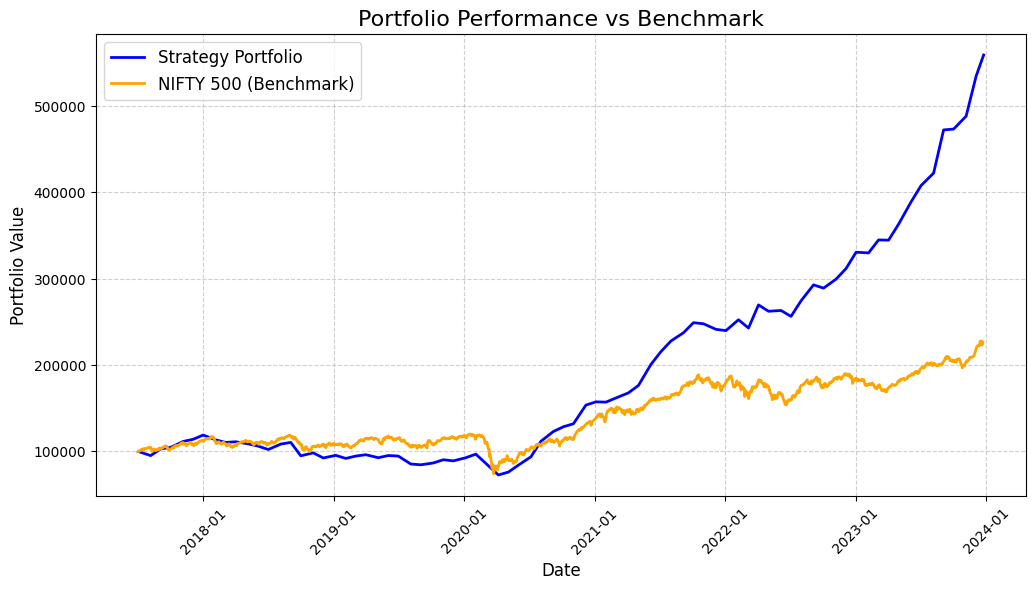

In [214]:
z_scores_df, z_scores_mean_df = z_score(START_DATE, END_DATE, 'All Cap', 0, 24, 16)
z_mean = False
strategy_df = backtest('2016-07-01', '2025-07-11', z_mean, 'All Cap', 'monthly',100000, 30, 0.0, 24)
print(strategy_df)
plot_strategy_vs_benchmark(strategy_df)

In [215]:


data = pd.read_csv(
    'data/nifty500/nifty500_daily_ohlcv.csv',
    index_col=0, header=[0,1], parse_dates=True
)

# tickers = data.columns.get_level_values(0).unique()[:500]
# data = data.loc[:, data.columns.get_level_values(0).isin(tickers)]

initial_value = 1000000.0
backtester = Backtester(data, initial_value)
backtester.run()
backtester.all_signals.to_csv('results/signals.csv')
print(backtester.portfolio_value)
pf = backtester.vectorbt_run()


100%|██████████| 364/364 [00:02<00:00, 181.34it/s]


2683524.2842588425
+----------------------------+----------------------------+
| Metric                     | Value                      |
|----------------------------+----------------------------|
| Start                      | 2017-01-02 00:00:00        |
| End                        | 2023-12-25 00:00:00        |
| Period                     | 365 days 00:00:00          |
| Start Value                | 1000000.0                  |
| End Value                  | 2683524.2842588425         |
| Total Return [%]           | 168.35242842588426         |
| Benchmark Return [%]       | 411.43474667175593         |
| Max Gross Exposure [%]     | 99.44054864485138          |
| Total Fees Paid            | 0.0                        |
| Max Drawdown [%]           | 21.55181543375198          |
| Max Drawdown Duration      | 80 days 00:00:00           |
| Total Trades               | 174                        |
| Total Closed Trades        | 144                        |
| Total Open Trades  

In [216]:
import plotly.graph_objects as go

stats_eq = pf.stats()
eq_curve = pf.value()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=eq_curve.index,
    y=eq_curve.values,
    mode='lines',
    name='Equity Curve',
    line=dict(color='green', width=3)
))
fig.update_layout(
    title='Portfolio Equity Curve',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white'
)
fig.show(renderer="browser")


In [217]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

returns = eq_curve.pct_change().fillna(0)
cum_max = eq_curve.cummax()
drawdown = (eq_curve - cum_max) / cum_max
mean_ret = returns.mean()
median_ret = returns.median()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Daily Returns', 'Drawdown Curve'))
fig.add_trace(
    go.Histogram(
        x=returns,
        nbinsx=50,
        marker_color='orange',
        marker_line_color='white',
        marker_line_width=1,
        opacity=0.8,
        name='Returns'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=drawdown.index,
        y=drawdown.values,
        mode='lines',
        line=dict(color='red', width=2),
        name='Drawdown'
    ),
    row=1, col=2
)

fig.update_xaxes(
    title_text='Return',
    row=1, col=1,
    nticks=20,
    showgrid=True
)
fig.update_yaxes(
    title_text='Frequency',
    row=1, col=1,
    showgrid=True
)

fig.update_xaxes(
    title_text='Date',
    row=1, col=2,
    showgrid=False
)
fig.update_yaxes(
    title_text='Drawdown',
    row=1, col=2,
    showgrid=True
)

fig.update_layout(
    title_text='Returns Distribution & Drawdown',
    bargap=0.1,               
    template='plotly_white',
    showlegend=False,
    width=900,
    height=400
)

fig.show(renderer="browser")
